# Probe analysis — run comparison (heatmap + radar)

This notebook loads the CSVs produced by the probe pipeline and generates:

1. Heatmaps (small multiples by preprocessing regime)
2. Radar charts (2×2; individual runs per regime)


In [53]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="white", context="paper")
except Exception:
    sns = None

# Notebook lives under scripts/analysis/notebooks/
OUT_DIR = Path("../../../analysis/embeddings_probe")
TEST_SCORES = OUT_DIR / "test_scores.csv"
EMBED_METRICS = OUT_DIR / "embedding_metrics.csv"

# Which metrics to include (initial guess; refine later)
# (name, higher_is_better, plot_label)
METRICS = [
    # classification
    ("auroc", True, "AUROC"),
    ("ap", True, "AP"),
    ("pauc_fpr0.05", True, "pAUC@0.05"),
    ("tpr_top0.05", True, "TPR@Top5%"),
    # embedding (enc)
    ("CAC_1", True, "CAC(1)"),
    ("CAD_1", False, "CAD(1)"),
    ("GPU_1", True, "GPU(1)"),
]

# Optional manual inversion override (metric -> invert)
# If a metric is 'lower is better', set invert=True.
INVERT: dict[str, bool] = {}

NORMALIZE = "minmax"  # or "none"
NORMALIZE_SCOPE = "global"  # "global" or "per_regime"

label_map = {m[0]: m[2] for m in METRICS}
metric_cols = [m[0] for m in METRICS]

scores = pd.read_csv(TEST_SCORES)
if EMBED_METRICS.exists():
    emb = pd.read_csv(EMBED_METRICS)
    if "space" in emb.columns:
        emb = emb[emb["space"].astype(str) == "enc"].copy()
    df = scores.merge(
        emb.drop(columns=[c for c in ["track", "preprocessing", "N"] if c in emb.columns], errors="ignore"),
        on="run_id",
        how="left",
        suffixes=("", "__emb"),
    )
else:
    df = scores.copy()


def infer_regime(row: pd.Series) -> str:
    pre = str(row.get("preprocessing", "")).strip()
    rid = str(row.get("run_id", "")).strip()
    text = f"{pre} {rid}".lower()
    if "bp-sc-norm" in text or "sc-norm" in text:
        return "bp-sc-norm"
    if "bp-sc" in text or "-sc-" in text or " sc" in text:
        return "bp-sc"
    return "bp"


df["run_id"] = df["run_id"].astype(str)
df["track"] = df.get("track", "").astype(str)
df["regime"] = df.apply(infer_regime, axis=1)

use = df[["run_id", "track", "regime"] + [c for c in metric_cols if c in df.columns]].copy()
for c in metric_cols:
    if c in use.columns:
        use[c] = pd.to_numeric(use[c], errors="coerce")


def normalize_minmax(series: pd.Series) -> pd.Series:
    x = series.astype(float)
    lo = np.nanmin(x.to_numpy())
    hi = np.nanmax(x.to_numpy())
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return x * np.nan
    return (x - lo) / (hi - lo)


def apply_metric_directions(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    for name, higher_is_better, _label in METRICS:
        if name not in out.columns:
            continue
        invert = INVERT.get(name, False) or (not higher_is_better)
        if invert:
            out[name] = -out[name]
    return out


use_dir = apply_metric_directions(use)

if NORMALIZE == "minmax":
    if NORMALIZE_SCOPE == "global":
        for name, _hib, _label in METRICS:
            if name in use_dir.columns:
                use_dir[name] = normalize_minmax(use_dir[name])
    else:
        for reg, sub_idx in use_dir.groupby("regime").groups.items():
            for name, _hib, _label in METRICS:
                if name in use_dir.columns:
                    use_dir.loc[sub_idx, name] = normalize_minmax(use_dir.loc[sub_idx, name])

use_dir


,run_id,track,regime,auroc,ap,pauc_fpr0.05,tpr_top0.05,CAC_1,CAD_1,GPU_1
0,t1-exp01-bp-bce,t1,bp,0.981984,0.883695,0.921637,0.979675,0.992802,0.435272,0.438506
1,t1-exp02-bp-bce-rot10,t1,bp,0.975376,0.908917,0.944917,0.973577,1.000000,0.334791,0.318439
2,t1-exp03-bp-focal,t1,bp,1.000000,1.000000,1.000000,0.993902,0.970560,0.402272,0.399020
3,t1-exp04-bp-focal-rot10,t1,bp,0.993706,0.972633,0.977674,0.983740,0.943122,0.330431,0.310171
4,t1-exp05-bp-rat,t1,bp,0.881921,0.740551,0.831854,0.873984,0.696574,0.195443,0.147978
5,t1-exp06-bp-rat-rot10,t1,bp,0.947524,0.933126,0.970344,1.000000,0.915266,0.000000,0.000000
6,t1-exp07-bp-sc-bce,t1,bp-sc,0.952796,0.840601,0.878327,0.932927,0.950002,0.289191,0.262377
7,t1-exp08-bp-sc-focal,t1,bp-sc,0.946111,0.834472,0.871475,0.906504,0.828230,0.290001,0.257344
8,t1-exp09-bp-sc-rat,t1,bp-sc,0.896738,0.834571,0.931461,0.955285,0.839860,0.023139,0.014377
9,t1-exp10-bp-sc-norm-bce,t1,bp-sc-norm,0.478124,0.165777,0.223480,0.290650,0.141930,0.958234,0.977935


/tmp/ipykernel_86957/1094310253.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


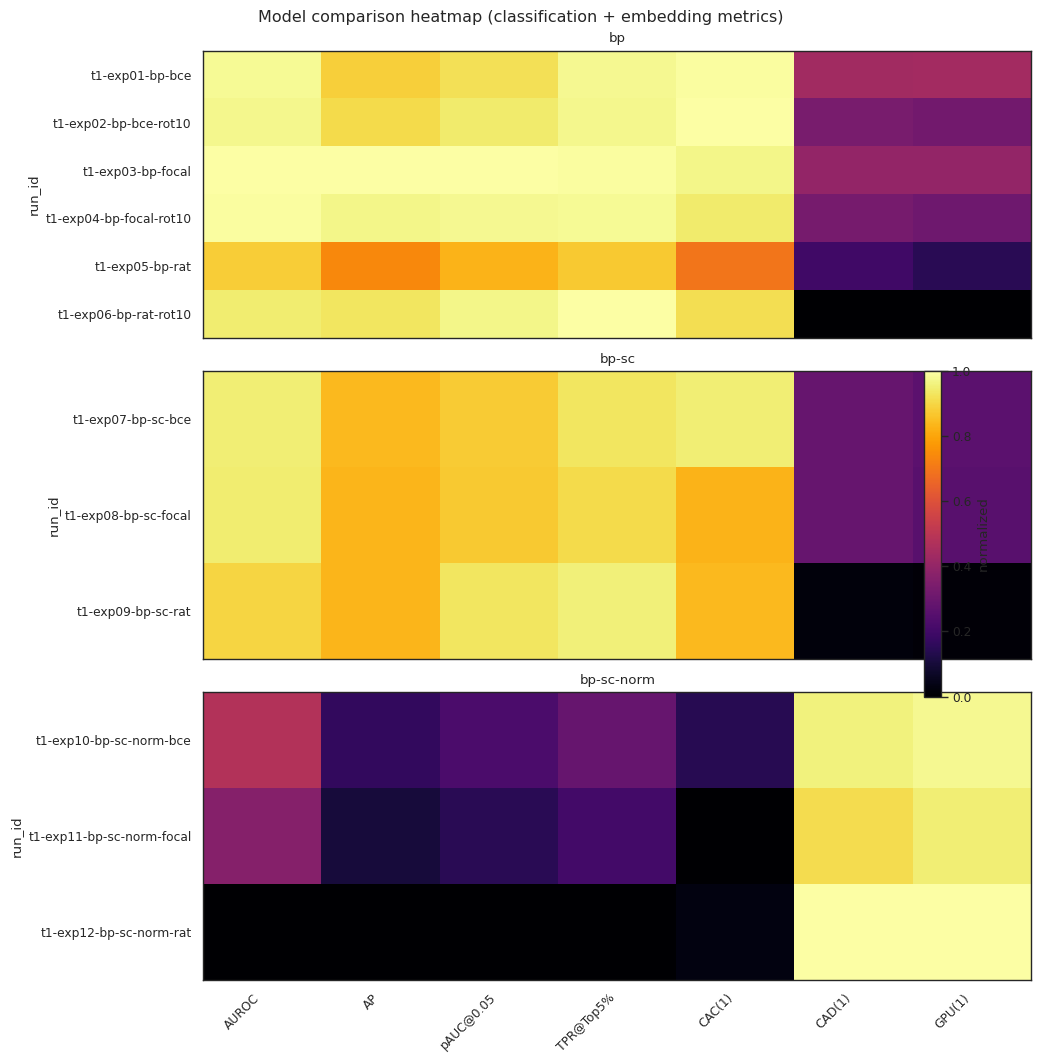

In [54]:
# Heatmaps (small multiples by preprocessing regime)
# - magma colormap
# - stacked vertically

regimes = ["bp", "bp-sc", "bp-sc-norm"]
present = [r for r in regimes if r in set(use_dir["regime"])]
if not present:
    present = sorted(use_dir["regime"].unique().tolist())

metric_cols_present = [c for c in metric_cols if c in use_dir.columns]
labels = [label_map.get(c, c) for c in metric_cols_present]

nrows = len(present)
fig, axs = plt.subplots(nrows=nrows, ncols=1, figsize=(10.5, 3.6 * nrows), sharex=True)
if nrows == 1:
    axs = [axs]

images = []
for ax, reg in zip(axs, present):
    sub = use_dir[use_dir["regime"] == reg].copy()
    sub = sub.sort_values(["track", "run_id"]).set_index("run_id")
    mat = sub[metric_cols_present].rename(columns=label_map)

    arr = mat.to_numpy(dtype=float)
    if NORMALIZE == "minmax":
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = float(np.nanmin(arr)), float(np.nanmax(arr))

    im = ax.imshow(arr, aspect="auto", cmap="inferno", vmin=vmin, vmax=vmax)
    images.append(im)

    ax.set_title(reg)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index)
    ax.set_ylabel("run_id")

    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(labels, rotation=45, ha="right")

cbar = fig.colorbar(images[-1], ax=axs, fraction=0.02, pad=0.02)
cbar.set_label("normalized" if NORMALIZE == "minmax" else "value")

fig.suptitle("Model comparison heatmap (classification + embedding metrics)")
plt.tight_layout()
plt.show()


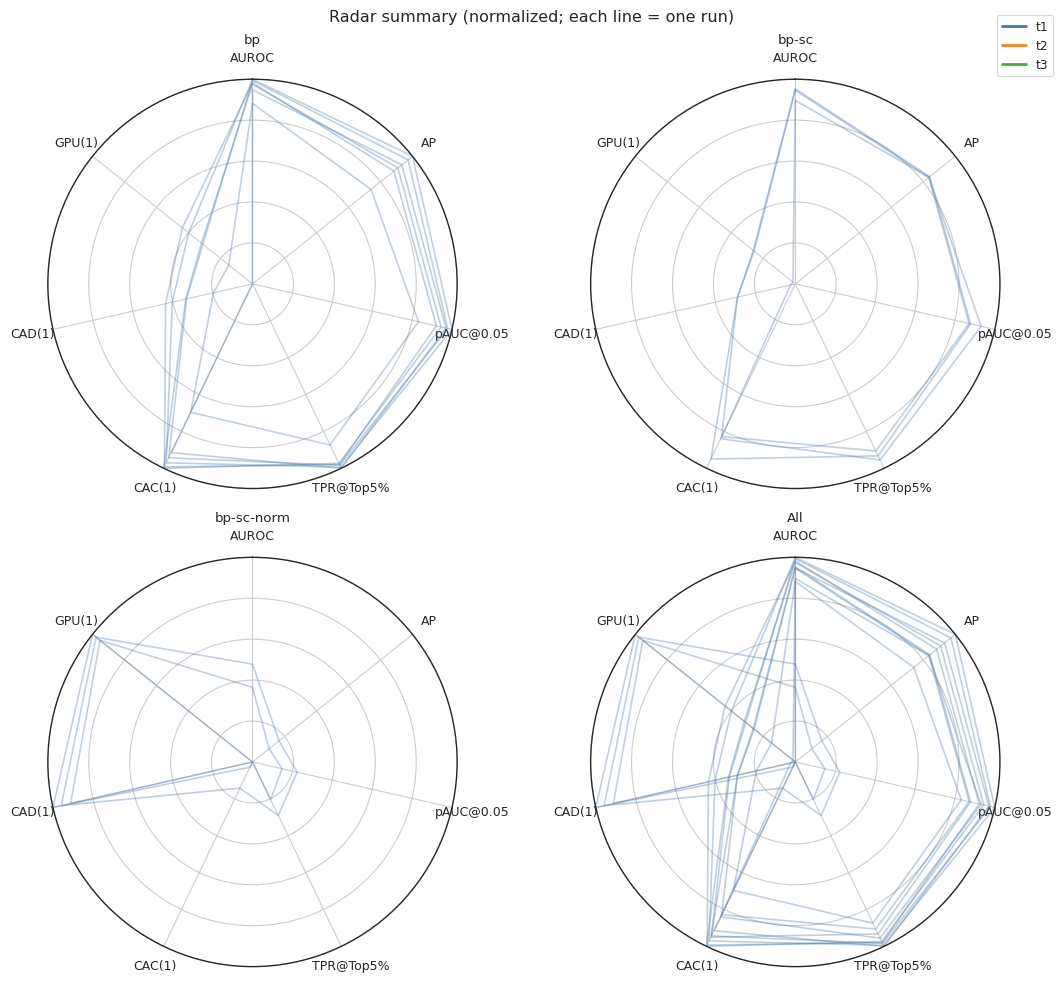

In [55]:
# Radar charts (2×2): show individual runs as lines (per regime)

def radar_angles(n: int) -> np.ndarray:
    a = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return np.concatenate([a, [a[0]]])


def radar_values(vals: np.ndarray) -> np.ndarray:
    vals = np.asarray(vals, dtype=float)
    return np.concatenate([vals, [vals[0]]])


metric_cols_present = [c for c in metric_cols if c in use_dir.columns]
labels = [label_map.get(c, c) for c in metric_cols_present]
angles = radar_angles(len(metric_cols_present))

panels = [
    ("bp", use_dir[use_dir["regime"] == "bp"]),
    ("bp-sc", use_dir[use_dir["regime"] == "bp-sc"]),
    ("bp-sc-norm", use_dir[use_dir["regime"] == "bp-sc-norm"]),
    ("All", use_dir),
]

track_colors = {"t1": "#4C78A8", "t2": "#F58518", "t3": "#54A24B"}

fig, axs = plt.subplots(figsize=(11, 10), nrows=2, ncols=2, subplot_kw=dict(polar=True))

for ax, (title, sub) in zip(axs.ravel(), panels):
    if sub.empty:
        ax.axis("off")
        continue

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    for _, row in sub.sort_values(["track", "run_id"]).iterrows():
        track = str(row.get("track", ""))
        vals = row[metric_cols_present].to_numpy(dtype=float)
        ax.plot(
            angles,
            radar_values(vals),
            color=track_colors.get(track, "#333333"),
            alpha=0.35,
            linewidth=1.2,
        )

    ax.set_title(title)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels([])
    if NORMALIZE == "minmax":
        ax.set_ylim(0.0, 1.0)

handles = [plt.Line2D([0], [0], color=c, lw=2) for c in track_colors.values()]
labels_legend = list(track_colors.keys())
fig.legend(handles, labels_legend, loc="upper right", bbox_to_anchor=(0.98, 0.98))
fig.suptitle("Radar summary (normalized; each line = one run)")
plt.tight_layout()
plt.show()


Pearson r (all runs): 0.979 (N=12)
Pearson r (t1): 0.979 (N=12)


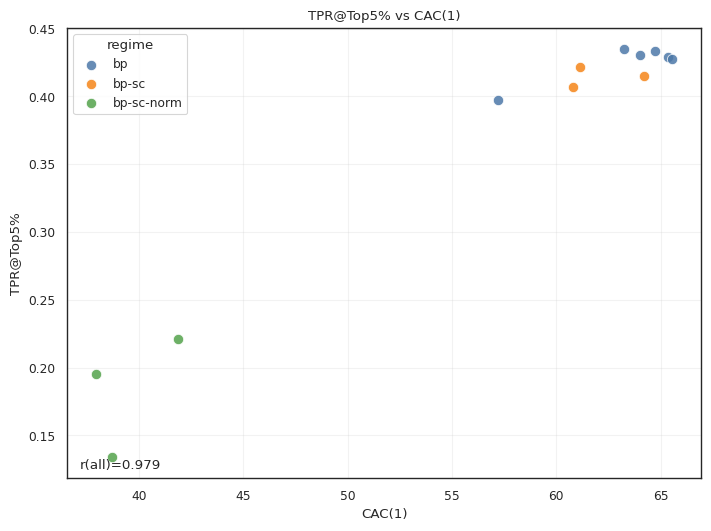

In [56]:
# Relationship: TPR@Top5% vs CAC(1)

cols = ["run_id", "track", "regime", "tpr_top0.05", "CAC_1"]
plot_df = df[[c for c in cols if c in df.columns]].copy()
plot_df["tpr_top0.05"] = pd.to_numeric(plot_df.get("tpr_top0.05"), errors="coerce")
plot_df["CAC_1"] = pd.to_numeric(plot_df.get("CAC_1"), errors="coerce")
plot_df = plot_df.dropna(subset=["tpr_top0.05", "CAC_1"]).copy()

def pearsonr_np(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size < 3:
        return float("nan")
    if float(np.std(x)) == 0.0 or float(np.std(y)) == 0.0:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])

r_all = pearsonr_np(plot_df["tpr_top0.05"].to_numpy(), plot_df["CAC_1"].to_numpy())
print(f"Pearson r (all runs): {r_all:.3f} (N={len(plot_df)})")
for trk, sub in plot_df.groupby("track"):
    r = pearsonr_np(sub["tpr_top0.05"].to_numpy(), sub["CAC_1"].to_numpy())
    print(f"Pearson r ({trk}): {r:.3f} (N={len(sub)})")

regime_colors = {"bp": "#4C78A8", "bp-sc": "#F58518", "bp-sc-norm": "#54A24B"}

fig, ax = plt.subplots(figsize=(7.2, 5.4))
for reg, sub in plot_df.groupby("regime"):
    ax.scatter(
        sub["CAC_1"],
        sub["tpr_top0.05"],
        s=55,
        alpha=0.85,
        label=reg,
        color=regime_colors.get(str(reg), "#333333"),
        edgecolor="white",
        linewidth=0.6,
    )

ax.set_xlabel("CAC(1)")
ax.set_ylabel("TPR@Top5%")
ax.set_title("TPR@Top5% vs CAC(1)")
ax.grid(True, alpha=0.25)
ax.legend(title="regime")
ax.text(0.02, 0.02, f"r(all)={r_all:.3f}", transform=ax.transAxes)
plt.tight_layout()
plt.show()


/tmp/ipykernel_86957/2295301166.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(data_eff, labels=order, patch_artist=True)
/tmp/ipykernel_86957/2295301166.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_p2, labels=order, patch_artist=True)
/tmp/ipykernel_86957/2295301166.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


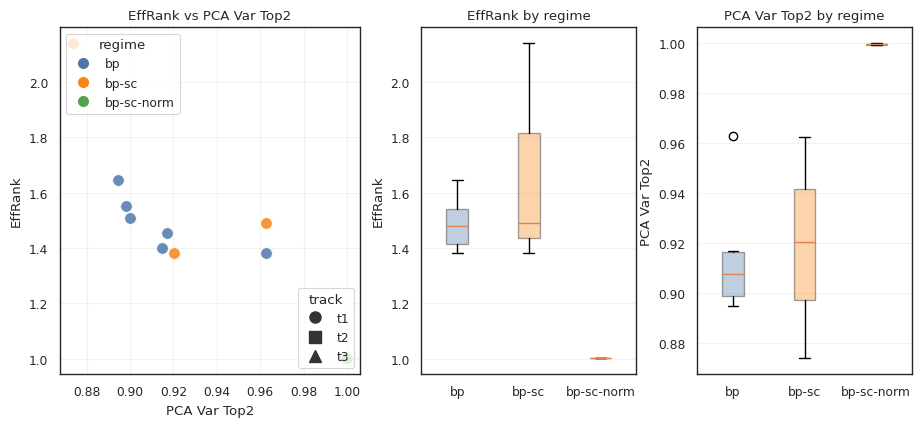

In [57]:
# EffRank + PCA Var Top2 (embedding diagnostics)
# Use these as descriptive collapse/anisotropy indicators, not as primary evidence.

cols = ["run_id", "track", "regime", "eff_rank", "pca_var_top2"]
z = df[[c for c in cols if c in df.columns]].copy()
z["eff_rank"] = pd.to_numeric(z.get("eff_rank"), errors="coerce")
z["pca_var_top2"] = pd.to_numeric(z.get("pca_var_top2"), errors="coerce")
z = z.dropna(subset=["eff_rank", "pca_var_top2"]).copy()

regime_colors = {"bp": "#4C78A8", "bp-sc": "#F58518", "bp-sc-norm": "#54A24B"}
track_markers = {"t1": "o", "t2": "s", "t3": "^"}

fig = plt.figure(figsize=(11, 4.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.4, 1.0, 1.0], wspace=0.25)

# (A) Scatter: PCA Var Top2 vs EffRank
ax0 = fig.add_subplot(gs[0, 0])
for (reg, trk), sub in z.groupby(["regime", "track"], dropna=False):
    ax0.scatter(
        sub["pca_var_top2"],
        sub["eff_rank"],
        s=70,
        alpha=0.85,
        color=regime_colors.get(str(reg), "#333333"),
        marker=track_markers.get(str(trk), "o"),
        edgecolor="white",
        linewidth=0.6,
    )

ax0.set_xlabel("PCA Var Top2")
ax0.set_ylabel("EffRank")
ax0.set_title("EffRank vs PCA Var Top2")
ax0.grid(True, alpha=0.25)

# Legends
handles_reg = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=c, markeredgecolor="white", markersize=9)
    for c in regime_colors.values()
]
labels_reg = list(regime_colors.keys())
handles_trk = [
    plt.Line2D([0], [0], marker=m, color="#333333", linestyle="none", markersize=8)
    for m in track_markers.values()
]
labels_trk = list(track_markers.keys())
leg1 = ax0.legend(handles_reg, labels_reg, title="regime", loc="upper left", frameon=True)
ax0.add_artist(leg1)
ax0.legend(handles_trk, labels_trk, title="track", loc="lower right", frameon=True)

# (B) EffRank by regime
ax1 = fig.add_subplot(gs[0, 1])
order = [r for r in ["bp", "bp-sc", "bp-sc-norm"] if r in set(z["regime"].astype(str))]
if not order:
    order = sorted(z["regime"].astype(str).unique().tolist())
data_eff = [z.loc[z["regime"].astype(str) == r, "eff_rank"].to_numpy() for r in order]
bp1 = ax1.boxplot(data_eff, labels=order, patch_artist=True)
for patch, r in zip(bp1["boxes"], order):
    patch.set_facecolor(regime_colors.get(str(r), "#cccccc"))
    patch.set_alpha(0.35)
ax1.set_title("EffRank by regime")
ax1.set_ylabel("EffRank")
ax1.grid(True, axis="y", alpha=0.25)

# (C) PCA Var Top2 by regime
ax2 = fig.add_subplot(gs[0, 2])
data_p2 = [z.loc[z["regime"].astype(str) == r, "pca_var_top2"].to_numpy() for r in order]
bp2 = ax2.boxplot(data_p2, labels=order, patch_artist=True)
for patch, r in zip(bp2["boxes"], order):
    patch.set_facecolor(regime_colors.get(str(r), "#cccccc"))
    patch.set_alpha(0.35)
ax2.set_title("PCA Var Top2 by regime")
ax2.set_ylabel("PCA Var Top2")
ax2.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


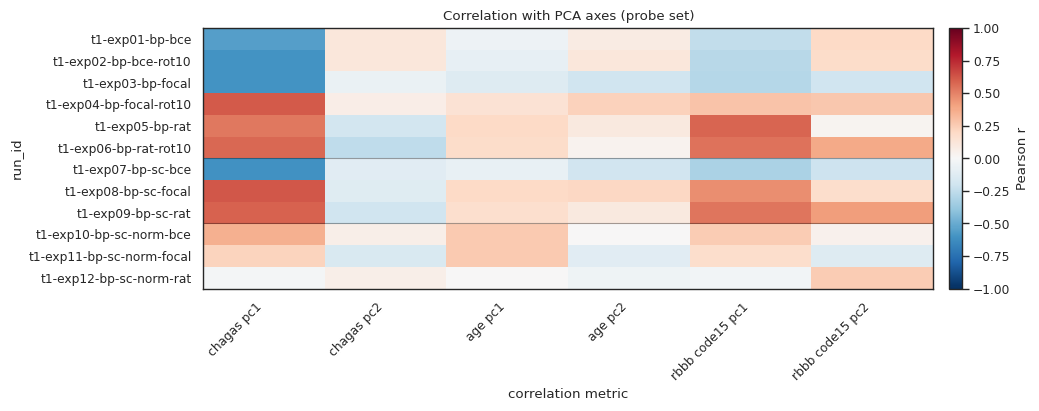

/tmp/ipykernel_86957/395058273.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/tmp/ipykernel_86957/395058273.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/tmp/ipykernel_86957/395058273.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)


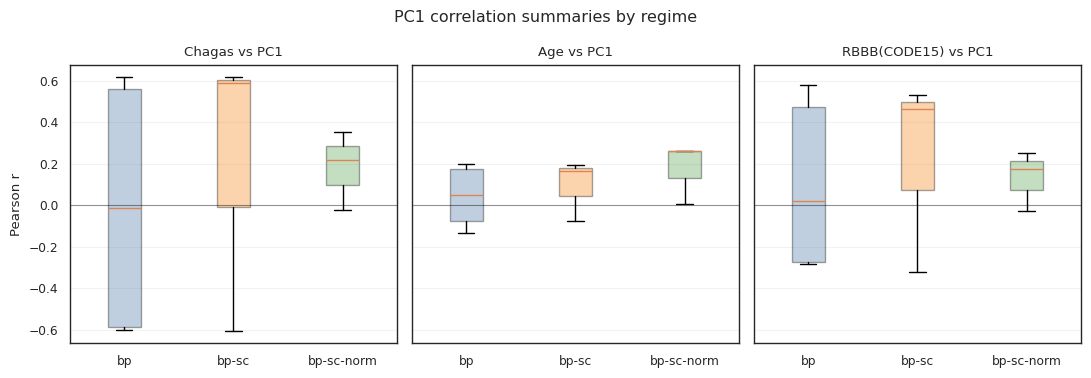

/tmp/ipykernel_86957/395058273.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/tmp/ipykernel_86957/395058273.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/tmp/ipykernel_86957/395058273.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)


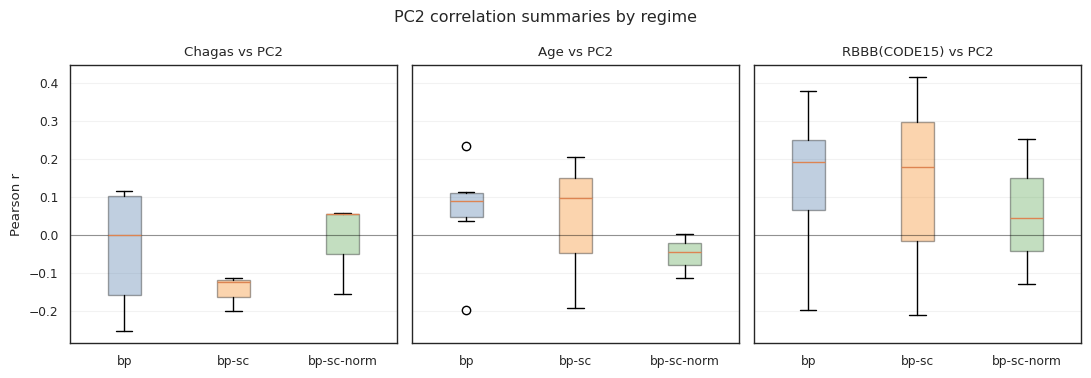

In [58]:
# PCA correlation metrics (metadata vs PCA axes)

corr_cols = [
    "run_id",
    "track",
    "regime",
    "corr_chagas_pc1",
    "corr_chagas_pc2",
    "corr_age_pc1",
    "corr_age_pc2",
    "corr_rbbb_code15_pc1",
    "corr_rbbb_code15_pc2",
]

c = df[[x for x in corr_cols if x in df.columns]].copy()
for col in c.columns:
    if col.startswith("corr_"):
        c[col] = pd.to_numeric(c[col], errors="coerce")
c = c.dropna(axis=0, how="all", subset=[col for col in c.columns if col.startswith("corr_")]).copy()

# Heatmap (runs × correlation metrics), grouped by regime
heat_cols = [col for col in c.columns if col.startswith("corr_")]
c_sorted = c.sort_values(["regime", "track", "run_id"]).set_index("run_id")
mat = c_sorted[heat_cols]

fig, ax = plt.subplots(figsize=(10.5, max(4.0, 0.35 * len(mat))))
im = ax.imshow(mat.to_numpy(dtype=float), aspect="auto", cmap="RdBu_r", vmin=-1.0, vmax=1.0)
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(mat.index)
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels([h.replace("corr_", "").replace("_", " ") for h in mat.columns], rotation=45, ha="right")
ax.set_title("Correlation with PCA axes (probe set)")
ax.set_xlabel("correlation metric")
ax.set_ylabel("run_id")
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Pearson r")

# Draw separators between regimes for readability
if "regime" in c_sorted.columns:
    regimes = c_sorted["regime"].astype(str).to_numpy()
    for i in range(1, len(regimes)):
        if regimes[i] != regimes[i-1]:
            ax.axhline(i - 0.5, color="black", linewidth=0.8, alpha=0.35)

plt.tight_layout()
plt.show()

# Summary boxplots by regime for PC1 correlations (quick comparability)
fig, axs = plt.subplots(1, 3, figsize=(11.0, 3.8), sharey=True)
pairs = [
    ("corr_chagas_pc1", "Chagas vs PC1"),
    ("corr_age_pc1", "Age vs PC1"),
    ("corr_rbbb_code15_pc1", "RBBB(CODE15) vs PC1"),
]
order = [r for r in ["bp", "bp-sc", "bp-sc-norm"] if r in set(c["regime"].astype(str))]
if not order:
    order = sorted(c["regime"].astype(str).unique().tolist())
regime_colors = {"bp": "#4C78A8", "bp-sc": "#F58518", "bp-sc-norm": "#54A24B"}
for ax, (col, ttl) in zip(axs, pairs):
    if col not in c.columns:
        ax.axis("off")
        continue
    data = [c.loc[c["regime"].astype(str) == r, col].to_numpy(dtype=float) for r in order]
    bp = ax.boxplot(data, labels=order, patch_artist=True)
    for patch, r in zip(bp["boxes"], order):
        patch.set_facecolor(regime_colors.get(str(r), "#cccccc"))
        patch.set_alpha(0.35)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(ttl)
    ax.grid(True, axis="y", alpha=0.25)
axs[0].set_ylabel("Pearson r")
fig.suptitle("PC1 correlation summaries by regime")
plt.tight_layout()
plt.show()

# Summary boxplots by regime for PC2 correlations
fig, axs = plt.subplots(1, 3, figsize=(11.0, 3.8), sharey=True)
pairs2 = [
    ("corr_chagas_pc2", "Chagas vs PC2"),
    ("corr_age_pc2", "Age vs PC2"),
    ("corr_rbbb_code15_pc2", "RBBB(CODE15) vs PC2"),
]
for ax, (col, ttl) in zip(axs, pairs2):
    if col not in c.columns:
        ax.axis("off")
        continue
    data = [c.loc[c["regime"].astype(str) == r, col].to_numpy(dtype=float) for r in order]
    bp = ax.boxplot(data, labels=order, patch_artist=True)
    for patch, r in zip(bp["boxes"], order):
        patch.set_facecolor(regime_colors.get(str(r), "#cccccc"))
        patch.set_alpha(0.35)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(ttl)
    ax.grid(True, axis="y", alpha=0.25)
axs[0].set_ylabel("Pearson r")
fig.suptitle("PC2 correlation summaries by regime")
plt.tight_layout()
plt.show()
